# Results VPD

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE' # without this python may crash when plotting from matplotlib
import sys
from shutil import copyfile

from IPython.display import display, HTML

import numpy as np
import torch
import pandas as pd
from copy import deepcopy

import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size':14})
plt.rcParams.update({'font.family':'serif'})
import matplotlib.lines as mlines

In [3]:
from BufferStockModel import BufferStockModelClass

In [4]:
parent_directory = os.path.abspath('..')
sys.path.append(parent_directory)
from plot_funcs import load_all, convergence_plot

## 1. <a id='toc1_'></a>[Load data](#toc2_)                       [&#8593;](#toc0_)

In [5]:
folder_load = '../output/'
folder = '../output/results'
algonames = ['DeepSimulate','DeepFOC','DeepVPD'] 
Ds = [0]

In [6]:
copyfile(os.path.join(folder_load,'BufferStockModel_DP_0D.pt'),
            os.path.join(folder_load,'BufferStockModelVPD_DP_0D.pt'))

'../output/BufferStockModelVPD_DP_0D.pt'

In [7]:
models = load_all(folder_load,'BufferStockModelVPD')

DP 0D


DeepFOC 0D


DeepSimulate 0D


DeepVPDBackward 0D


DeepVPDBackward 0D pure


DeepVPD 0D


DeepVPD 0D FOC


DeepVPD 0D NNs3


DeepVPD 0D NNs3FOC


DeepVPD 0D NNs5


Move simulation to numpy:

In [8]:
for model in models.values():
    for k,v in model.sim.__dict__.items():
        if isinstance(v,torch.Tensor):
            model.sim.__dict__[k] = v.numpy()

## 3. <a id='toc1_'></a>[Convergence](#toc2_) 

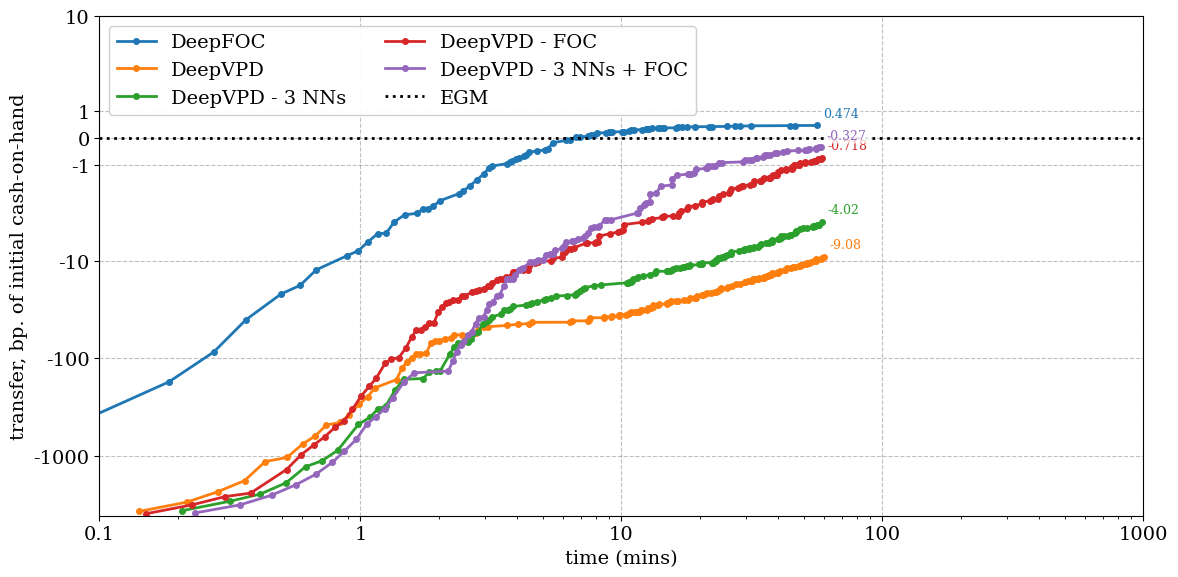

In [9]:
xlim = [0.1,1000]
specs = {
    ('DeepFOC','0D'):'DeepFOC',
    ('DeepVPD','0D'):'DeepVPD',
    ('DeepVPD','0D','NNs3'):'DeepVPD - 3 NNs',
    ('DeepVPD','0D','FOC'):'DeepVPD - FOC',
    ('DeepVPD','0D','NNs3FOC'):'DeepVPD - 3 NNs + FOC',
}
convergence_plot('BufferStockModelVPD',models,specs,DP=models[('DP','0D')],do_transfer=True,
                    xlim=xlim,ylim=[None,10],
                    folder=folder,postfix=f'_conv')

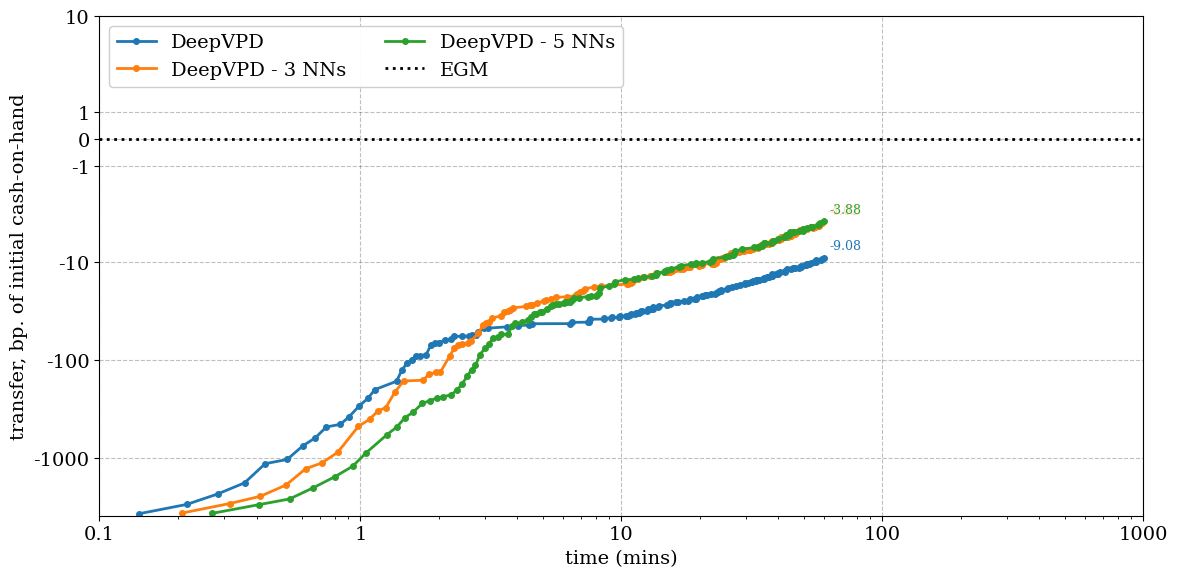

In [10]:
xlim = [0.1,1000]
specs = {
    ('DeepVPD','0D'):'DeepVPD',
    ('DeepVPD','0D','NNs3'):'DeepVPD - 3 NNs',
    ('DeepVPD','0D','NNs5'):'DeepVPD - 5 NNs',
}
convergence_plot('BufferStockModelVPD',models,specs,DP=models[('DP','0D')],do_transfer=True,
                    xlim=xlim,ylim=[None,10],
                    folder=folder,postfix=f'_conv_NNs')